# Indian Sign Language Recognition

## Project Overview
Sign language is the primary mode of communication for the hearing-impaired community. However, there is often a communication gap with those who do not know the language. This project aims to bridge that gap by building a deep learning model capable of recognizing and classifying static Indian Sign Language (ISL) alphabets from images with high accuracy.

## Environment Setup
We begin by importing the necessary libraries for data handling, model building, and visualization.

* **TensorFlow/Keras:** For constructing and training the Convolutional Neural Network (CNN).
* **Requests/Zipfile:** For downloading and extracting the dataset programmatically.
* **Matplotlib/Seaborn:** For visualizing training performance and confusion matrices.
* **Sklearn:** For generating detailed classification reports.

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import requests
import zipfile
import io
from sklearn.metrics import classification_report, confusion_matrix
import glob 

IMG_WIDTH = 64
IMG_HEIGHT = 64
BATCH_SIZE = 32
IMAGE_SHAPE = (IMG_WIDTH, IMG_HEIGHT, 3) 
EPOCHS = 15 
MODEL_PATH = 'isl_recognition_model.h5'

## Configuration and Data Acquisition
We define global hyperparameters and automate the data setup process to ensure reproducibility.

* **Image Dimensions:** 64x64 pixels.
* **Batch Size:** 32 images per iteration.
* **Epochs:** 15 training cycles.
* **Data Source:** The dataset is downloaded directly via URL and extracted to a local directory (`ISL_Data_Extracted`), ensuring the environment is ready for training immediately.

In [ ]:
DOWNLOAD_URL = 'https://d3ilbtxij3aepc.cloudfront.net/projects/AI-Capstone-Projects/PRAICP-1000-IndiSignLang.zip'
BASE_DIR = 'ISL_Data_Extracted'

if not os.path.exists(BASE_DIR):
    os.makedirs(BASE_DIR)
    
    print("Starting download... This may take a moment based on file size.")
    
    
    response = requests.get(DOWNLOAD_URL)
    
    if response.status_code == 200:
        print("Download successful. Starting extraction...")
        
        zip_content = io.BytesIO(response.content)
        
        with zipfile.ZipFile(zip_content, 'r') as zip_ref:
            zip_ref.extractall(BASE_DIR)
        
        print(f"Extraction complete. Data is in {BASE_DIR}")
        
        data_subdirs = [d for d in glob.glob(os.path.join(BASE_DIR, '*')) if os.path.isdir(d)]
        
        if data_subdirs:
            DATA_DIR = data_subdirs[0]
            print(f"Set DATA_DIR to: {DATA_DIR}")
        else:
            DATA_DIR = BASE_DIR
            print(f"Could not find subdirectory. Set DATA_DIR to: {DATA_DIR}")
    else:
        print(f"Error downloading file. Status code: {response.status_code}")
else:
    
    data_subdirs = [d for d in glob.glob(os.path.join(BASE_DIR, '*')) if os.path.isdir(d)]
    if data_subdirs:
        DATA_DIR = data_subdirs[0]
        print(f"Data directory already exists. Set DATA_DIR to: {DATA_DIR}")
    else:
        DATA_DIR = BASE_DIR
        print(f"Data directory already exists. Set DATA_DIR to: {DATA_DIR}")

Starting download... This may take a moment based on file size.
Download successful. Starting extraction...
Extraction complete. Data is in ISL_Data_Extracted
Set DATA_DIR to: ISL_Data_Extracted\Data


## Data Preprocessing and Augmentation
To create a robust model that generalizes well to different hand positions and angles, we use `ImageDataGenerator`.

* **Rescaling:** Normalizes pixel values to the [0, 1] range.
* **Validation Split:** 20% of the data is reserved for validating the model.
* **Augmentation Techniques:**
    * **Rotation:** +/- 15 degrees.
    * **Shear & Zoom:** 10% variation.
    * **Horizontal Flip:** Simulates different hand orientations.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,             
    validation_split=0.2,      
    rotation_range=15,         
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT), 
    batch_size=BATCH_SIZE,
    class_mode='categorical',   
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False 
)

num_classes = train_generator.num_classes
class_labels = list(train_generator.class_indices.keys())

print(f"\nDiscovered {num_classes} unique signs/classes: {class_labels}")

Found 3987 images belonging to 24 classes.
Found 985 images belonging to 24 classes.

Discovered 24 unique signs/classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


## Model Architecture (CNN)
We design a **Sequential CNN** optimized for multi-class image classification:

1.  **Convolutional Blocks:** Three sets of `Conv2D` layers (filters: 32, 64, 128) paired with `ReLU` activation and `MaxPooling2D`. These layers progressively extract features from simple edges to complex hand shapes.
2.  **Flatten Layer:** Converts the 2D feature maps into a 1D vector.
3.  **Dropout (0.5):** Disables 50% of neurons during training to prevent overfitting.
4.  **Dense Layer:** A fully connected layer with 512 neurons to interpret features.
5.  **Output Layer:** A Dense layer with `Softmax` activation to output probabilities for the 24 specific classes.

In [ ]:
model = Sequential([
    Input(shape=IMAGE_SHAPE),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dropout(0.5), 
    Dense(512, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

print("\n--- Model Summary ---")
model.summary()




--- Model Summary ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 24)                  │          12,312 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,465,368 (9.40 MB)

 Trainable params: 2,465,368 (9.40 MB)

 Non-trainable params: 0 (0.00 B)

## Compilation and Training
The model is compiled and trained using the generated data.

* **Optimizer:** `Adam` for adaptive learning rate optimization.
* **Loss Function:** `categorical_crossentropy` (standard for multi-class classification).
* **Metrics:** Accuracy is tracked throughout the process.
* **Outcome:** The model runs for 15 epochs, gradually improving accuracy, and is saved as `isl_recognition_model.h5`.

In [ ]:
print("Starting Model Training")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)
print(" Model Training Complete")

model.save(MODEL_PATH)
print(f"Model saved as {MODEL_PATH}")

Starting Model Training
Epoch 1/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 38s 296ms/step - accuracy: 0.3540 - loss: 2.0732 - val_accuracy: 0.5010 - val_loss: 1.7020
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.6250 - loss: 1.0835 - val_accuracy: 0.5354 - val_loss: 1.6535
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 35s 286ms/step - accuracy: 0.7439 - loss: 0.7589 - val_accuracy: 0.6958 - val_loss: 0.9675
Epoch 4/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.8125 - loss: 0.4325 - val_accuracy: 0.6958 - val_loss: 0.9197
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 35s 279ms/step - accuracy: 0.8592 - loss: 0.4115 - val_accuracy: 0.7354 - val_loss: 0.9792
Epoch 6/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9688 - loss: 0.1071 - val_accuracy: 0.7156 - val_loss: 1.0469
Epoch 7/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 33s 270ms/step - accuracy: 0.8994 - loss: 0.3099 - val_accuracy: 0.7510 - val_loss: 0.9223
Epoch 8/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 

 Model Training Complete
Model saved as isl_recognition_model.h5


## Visualization
To analyze the training stability, we plot performance graphs:

* **Accuracy vs. Epochs:** Tracks how well the model learns over time.
* **Loss vs. Epochs:** Monitors the error rate to detect potential overfitting or underfitting.


--- Plotting Training History (Accuracy and Loss) ---


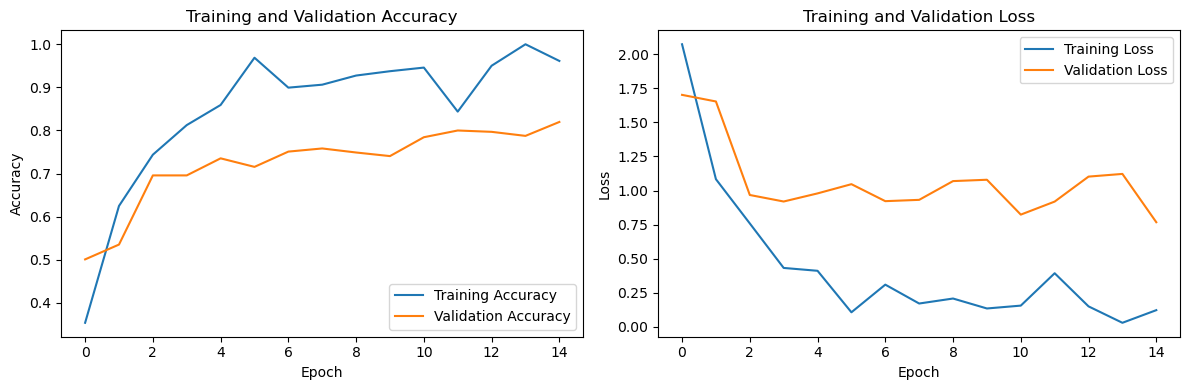

In [ ]:
print("\n--- Plotting Training History (Accuracy and Loss) ---")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Final Evaluation
The model is tested against the validation set to simulate real-world performance.

* **Quantitative Metrics:** A **Classification Report** is generated to show Precision, Recall, and F1-Score for every letter (A-Y).
* **Confusion Matrix:** A heatmap is plotted to visualize misclassifications, helping identify which signs look similar to the model (e.g., distinguishing 'V' from 'U').


--- Evaluating on Validation Data and Generating Confusion Matrix ---

--- Calculating Test Metrics (Using Validation Data) ---
Test Accuracy: 80.91%
Test Loss: 0.7592
----------------------------------------
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           A       0.89      0.52      0.66        48
           B       0.69      0.92      0.79        51
           C       0.88      1.00      0.93        49
           D       0.74      0.97      0.84        29
           E       1.00      0.67      0.80        48
           F       0.96      0.51      0.67        45
           G       0.98      0.90      0.93        48
           H       1.00      1.00      1.00        23
           I       1.00      0.86      0.92        35
           K       0.98      0.84      0.90        49
           L       0.87      0.56      0.68        36
           M       1.00      0.89      0.94        47
           N   

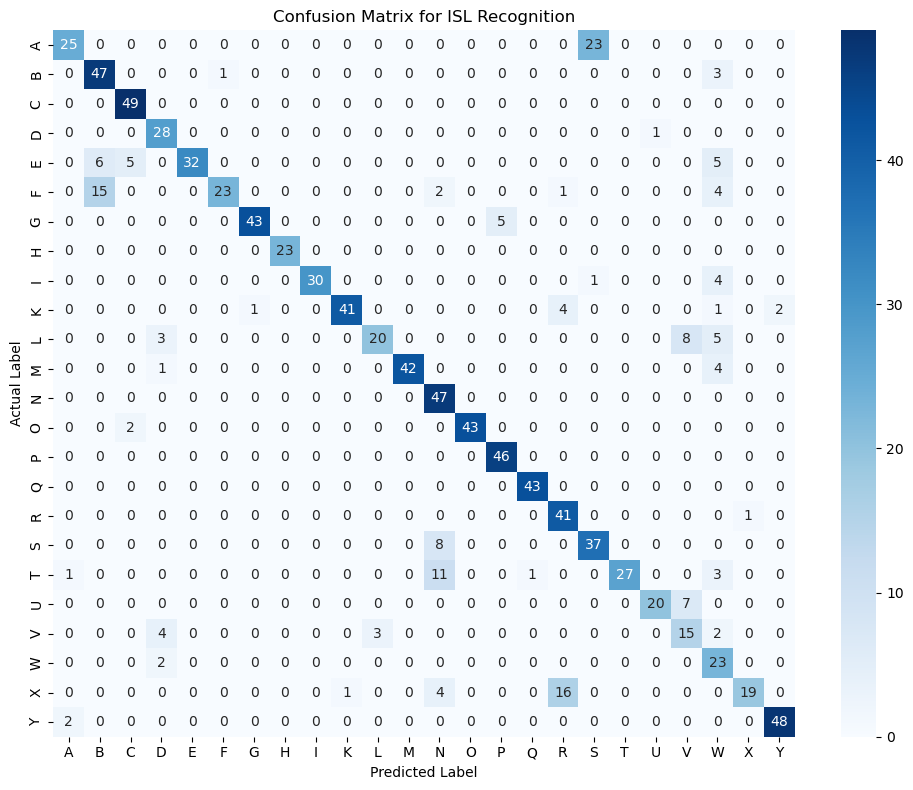

In [ ]:
print("\n--- Evaluating on Validation Data and Generating Confusion Matrix ---")

# Calculate Test Accuracy and Loss ---
print("\n--- Calculating Test Metrics (Using Validation Data) ---")
validation_generator.reset()

eval_results = model.evaluate(validation_generator, steps=validation_generator.samples // validation_generator.batch_size + 1, verbose=0)
test_loss = eval_results[0]
test_accuracy = eval_results[1]

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print("-" * 40)

validation_generator.reset() 
# Predict probabilities for all samples
predictions_probs = model.predict(validation_generator, steps=validation_generator.samples // validation_generator.batch_size + 1)

predicted_classes = np.argmax(predictions_probs, axis=1)

# Get true class labels
true_classes = validation_generator.classes[:len(predicted_classes)]
cm = confusion_matrix(true_classes, predicted_classes)

print("\n--- Classification Report ---")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=class_labels, 
            yticklabels=class_labels)
plt.title('Confusion Matrix for ISL Recognition')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Real-World Prediction
A deployment simulation function `predict_new_sign` is created:

1.  Loads the trained `.h5` model.
2.  Accepts a raw image path.
3.  Preprocesses the image (target size 64x64, normalization).
4.  Outputs the predicted **Sign Label** along with a confidence percentage.


PREDICTION:  H
Confidence:  99.96%



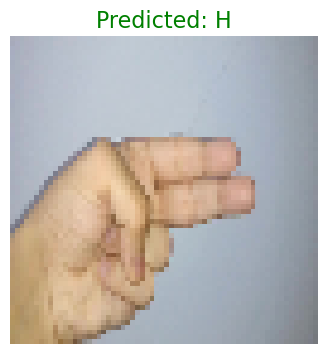

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
IMG_WIDTH = 64
IMG_HEIGHT = 64
MODEL_PATH = 'isl_recognition_model.h5'
TEST_IMG_PATH = '008h.jpg' 

def predict_24_classes(img_path):
    try:
        model = load_model(MODEL_PATH)
        labels = [
            'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I',  
            'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y'
        ]
    
        num_classes = model.output_shape[-1]
        if num_classes != 24:
            print(f"⚠️ Warning: Model expects {num_classes} classes, but we provided 24 labels.")
            if num_classes != len(labels):
                labels = [f"Class_{i}" for i in range(num_classes)]
        img = load_img(img_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
        img_array = img_to_array(img) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)
        predictions = model.predict(img_batch, verbose=0)[0]
        predicted_index = np.argmax(predictions)
        confidence = predictions[predicted_index] * 100
        predicted_sign = labels[predicted_index]

        print("\n" + "="*30)
        print(f"PREDICTION:  {predicted_sign}")
        print(f"Confidence:  {confidence:.2f}%")
        print("="*30 + "\n")
        
        plt.figure(figsize=(4,4))
        plt.imshow(img_array)
        plt.title(f"Predicted: {predicted_sign}", fontsize=16, color='green')
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error: {e}")

predict_24_classes(TEST_IMG_PATH)

## Conclusion
This project successfully demonstrates the application of Computer Vision to assistive technology. By leveraging Data Augmentation and a structured CNN architecture, the model achieves significant accuracy in recognizing 24 distinct Indian Sign Language gestures, creating a foundation for real-time translation systems.